# Family B — full backtest statistics and the parameter grid

Two jobs: (1) proper statistics for every carry book (Sharpe, NW t, max
drawdown, skew, worst day — both signs, 0/1/2× costs); (2) a pre-declared
grid over the intra-quarter richness fade — book × rank × threshold ×
exit fraction × max hold × direction — with the house discipline:
n-floored winner, deflated Sharpe at the FULL trial count, neighborhood
stability, chronological halves, mirrored sign tests, verdict taxonomy.

The sample now includes the backfilled SFRZ24/SFRU24 (the Sep-2024 event
contract sits in the books natively); older expiries join as the
background backfill lands — re-execution picks them up automatically.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(".")
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from famb_common import (
    TreeCtx, book_daily_pnl, build_book, intra_quarter_backtest, load_quotes,
    n_contracts, premium_surface, series_stats, sr3_forwards,
    trades_daily_pnl,
)
from linvol_grid_common import pick_winner
from BT.signals.deflated_sharpe import deflated_sharpe
from RVUtils.SFRRVLab.stats import verdict

DATA = Path("../data/famb")
BOOKS = ["FLY25", "FLY50", "DFLY", "STRG50", "STRG75"]
RANKS = [1, 2, 3]

quotes = load_quotes()
symbols = sorted(quotes["symbol"].unique())
fwd = sr3_forwards(symbols)
fwd["as_of"] = pd.to_datetime(fwd["as_of"])
surface = premium_surface(quotes, fwd)
fwd_idx = fwd.set_index(["as_of", "symbol"])["fwd_rate"].sort_index()
dates = pd.DatetimeIndex(sorted(quotes["as_of"].unique()))
tree = TreeCtx([d.date() for d in dates])
books = {(b, r): build_book(b, r, dates, surface, fwd_idx, tree)
         for b in BOOKS for r in RANKS}
print(f"quotes {len(quotes)} rows, {len(symbols)} symbols "
      f"({', '.join(s for s in symbols if s.endswith('24'))} backfilled), "
      f"{dates[0].date()} -> {dates[-1].date()}")

quotes 376503 rows, 26 symbols (SFRH24, SFRM24, SFRU24, SFRZ24 backfilled), 2021-02-04 -> 2026-07-28


## 1. Carry-book statistics, both signs

In [2]:
rows = []
for (book, rank), hs in books.items():
    if not hs:
        continue
    for mult, tag in ((0.0, "0x"), (1.0, "1x"), (2.0, "2x")):
        pnl = book_daily_pnl(hs, cost_mult=mult, n_legs=n_contracts(book))
        daily = pnl.groupby("as_of")["pnl_bp"].sum()
        for sign, sname in ((1.0, "long"), (-1.0, "short")):
            # costs are sign-invariant: flip marks/settle, keep costs
            g = pnl.copy()
            m = g["kind"].isin(["mark", "settle"])
            g.loc[m, "pnl_bp"] *= sign
            d = g.groupby("as_of")["pnl_bp"].sum()
            if mult == 1.0:
                st = series_stats(d)
                st.update(book=book, rank=rank, side=sname)
                rows.append(st)
stats = pd.DataFrame(rows)[
    ["book", "rank", "side", "days", "total_bp", "sharpe_ann", "nw_t",
     "max_dd_bp", "worst_day_bp", "skew"]]
print("=== carry books @1x costs ===")
print(stats.to_string(index=False))

=== carry books @1x costs ===
  book  rank  side  days  total_bp  sharpe_ann  nw_t  max_dd_bp  worst_day_bp  skew
 FLY25     1  long  1102     -60.0       -0.97 -2.17      -66.9         -6.42 -0.75
 FLY25     1 short  1102      41.0        0.66  1.51      -21.0         -4.20  0.79
 FLY25     2  long  1099     -31.1       -0.81 -2.08      -31.2         -3.44  0.18
 FLY25     2 short  1099      -4.9       -0.13 -0.33      -21.0         -4.03 -0.10
 FLY25     3  long  1064     -19.4       -0.68 -1.99      -21.9         -1.69  0.11
 FLY25     3 short  1064     -16.6       -0.59 -1.78      -19.3         -1.76 -0.03
 FLY50     1  long  1095     -80.7       -0.72 -1.47     -101.7        -11.87 -0.97
 FLY50     1 short  1095      60.7        0.54  1.11      -50.0         -6.20  1.00
 FLY50     2  long  1045     -43.3       -0.52 -1.10      -59.1         -9.08 -0.62
 FLY50     2 short  1045       7.3        0.09  0.19      -54.0         -6.88  0.68
 FLY50     3  long  1023     -24.0       -0.44

## 2. The intra-quarter grid (pre-declared, 720 configs)

In [3]:
GRID = dict(thr=(2.0, 3.0, 4.0, 6.0), exit_frac=(0.25, 0.5),
            max_hold=(5, 10, 15), direction=("fade", "momentum"))
grid_rows, trade_map = [], {}
for (book, rank), hs in books.items():
    if not hs:
        continue
    for thr in GRID["thr"]:
        for ef in GRID["exit_frac"]:
            for mh in GRID["max_hold"]:
                for dirn in GRID["direction"]:
                    tr = intra_quarter_backtest(
                        hs, thr_bp=thr, exit_frac=ef, max_hold=mh,
                        direction=dirn, cost_mult=1.0,
                        n_legs=n_contracts(book))
                    cfg = dict(book=book, rank=rank, thr=thr, exit_frac=ef,
                               max_hold=mh, direction=dirn)
                    if tr:
                        nets = np.array([t["net_bp"] for t in tr])
                        n2 = np.array([t["gross_bp"] - 2 * (t["gross_bp"]
                                       - t["net_bp"]) for t in tr])
                        se = nets.std(ddof=1) / np.sqrt(len(nets)) \
                            if len(nets) > 1 else np.nan
                        cfg.update(
                            n_trades=len(tr),
                            hit=round(float((nets > 0).mean()), 2),
                            total_gross_bp=round(float(sum(
                                t["gross_bp"] for t in tr)), 1),
                            net_1x_bp=round(float(nets.sum()), 1),
                            net_2x_bp=round(float(n2.sum()), 1),
                            avg_net_1x_bp=round(float(nets.mean()), 2),
                            t_stat=round(float(nets.mean() / se), 2)
                            if se and se > 0 else np.nan)
                    else:
                        cfg.update(n_trades=0, hit=np.nan,
                                   total_gross_bp=0.0, net_1x_bp=0.0,
                                   net_2x_bp=0.0, avg_net_1x_bp=np.nan,
                                   t_stat=np.nan)
                    grid_rows.append(cfg)
                    trade_map[len(grid_rows) - 1] = tr
league = pd.DataFrame(grid_rows)
league.to_parquet(DATA / "famb_grid_league.parquet", index=False)
live = league[league["n_trades"] > 0]
print(f"{len(league)} configs, {len(live)} produced trades")
cols = ["book", "rank", "thr", "exit_frac", "max_hold", "direction",
        "n_trades", "hit", "net_1x_bp", "net_2x_bp", "t_stat"]
print("\n=== top 12 by net@1x among n>=10 ===")
solid = live[live["n_trades"] >= 10]
print(solid.sort_values("net_1x_bp", ascending=False).head(12)[cols]
      .round(2).to_string(index=False))
print("\nsign test (median net@1x): "
      f"{live.groupby('direction')['net_1x_bp'].median().round(1).to_dict()}")

720 configs, 720 produced trades

=== top 12 by net@1x among n>=10 ===
  book  rank  thr  exit_frac  max_hold direction  n_trades  hit  net_1x_bp  net_2x_bp  t_stat
STRG75     1  4.0       0.25        15      fade        16 0.88       75.3       67.3    1.72
STRG75     1  4.0       0.50        15      fade        17 0.88       69.8       61.3    1.61
STRG75     1  4.0       0.25         5      fade        28 0.68       69.7       55.7    1.99
STRG75     1  4.0       0.50         5      fade        28 0.68       57.3       43.3    1.50
STRG50     1  6.0       0.25        15      fade        17 0.82       47.7       39.2    1.32
STRG75     1  6.0       0.25         5      fade        17 0.71       39.2       30.7    2.95
STRG75     2  6.0       0.50        10  momentum        55 0.29       38.9       11.4    0.68
STRG75     1  6.0       0.25        15      fade        10 0.80       35.8       30.8    1.55
STRG75     1  4.0       0.25        10      fade        21 0.76       33.9       23

## 3. The winner — full statistics, DSR, neighborhood, halves

In [4]:
w = pick_winner(live)
wi = int(w.name)
wt = trade_map[wi]
print("WINNER:", {k: w[k] for k in cols})
hs_w = books[(w["book"], int(w["rank"]))]
daily_w = trades_daily_pnl(wt, hs_w, cost_mult=1.0,
                           n_legs=n_contracts(w["book"]))
st = series_stats(daily_w)
print("daily-series stats @1x:", st)

nets = np.array([t["net_bp"] for t in wt])
sr_pp = (live["t_stat"] / np.sqrt(live["n_trades"].clip(lower=1))).dropna()
dsr = deflated_sharpe(nets, n_trials=len(league),
                      sr_variance=float(sr_pp.var(ddof=1))
                      if len(sr_pp) > 2 else None,
                      annualisation=1.0)
print(f"DSR at n_trials={len(league)}: dsr_prob={dsr['dsr_prob']:.3f}")

nb = league[(league["book"] == w["book"]) & (league["rank"] == w["rank"])
            & (league["direction"] == w["direction"])]
n_pos = int((nb["net_1x_bp"] > 0).sum())
print(f"neighborhood (same book/rank/direction, all thr x exit x hold): "
      f"{n_pos}/{len(nb)} positive, median "
      f"{nb['net_1x_bp'].median():+.1f}bp -> "
      + ("SUPPORTED" if n_pos > len(nb) / 2 else "ISLAND"))

tl = pd.DataFrame(wt)
mid = tl["entry"].min() + (tl["entry"].max() - tl["entry"].min()) / 2
for name, seg in (("H1", tl[tl["entry"] <= mid]),
                  ("H2", tl[tl["entry"] > mid])):
    print(f"  {name}: {len(seg)} trades  net {seg['net_bp'].sum():+.1f}bp  "
          f"hit {(seg['net_bp'] > 0).mean():.0%}" if len(seg)
          else f"  {name}: 0 trades")

med = float(league["net_1x_bp"].fillna(0.0).median())
v = verdict(net_bp_at_taker=float(w["net_2x_bp"]),
            net_bp_at_maker=float(w["total_gross_bp"]),
            dsr_prob=float(dsr["dsr_prob"]) if np.isfinite(
                dsr["dsr_prob"]) else 0.0,
            median_net_bp=med, n_trades=int(w["n_trades"]))
print(f"\nVERDICT (house taxonomy): {v}   "
      f"(median config net {med:+.1f}bp across {len(league)} trials)")

WINNER: {'book': 'STRG75', 'rank': np.int64(1), 'thr': np.float64(4.0), 'exit_frac': np.float64(0.25), 'max_hold': np.int64(15), 'direction': 'fade', 'n_trades': np.int64(16), 'hit': np.float64(0.88), 'net_1x_bp': np.float64(75.3), 'net_2x_bp': np.float64(67.3), 't_stat': np.float64(1.72)}
daily-series stats @1x: {'days': 236, 'total_bp': 75.3, 'sharpe_ann': 1.62, 'nw_t': 2.1, 'max_dd_bp': -19.7, 'worst_day_bp': -16.6, 'skew': 3.51}
DSR at n_trials=720: dsr_prob=0.000
neighborhood (same book/rank/direction, all thr x exit x hold): 16/24 positive, median +20.4bp -> SUPPORTED
  H1: 10 trades  net +55.3bp  hit 80%
  H2: 6 trades  net +20.0bp  hit 100%

VERDICT (house taxonomy): SELECTION-ARTIFACT   (median config net -51.5bp across 720 trials)


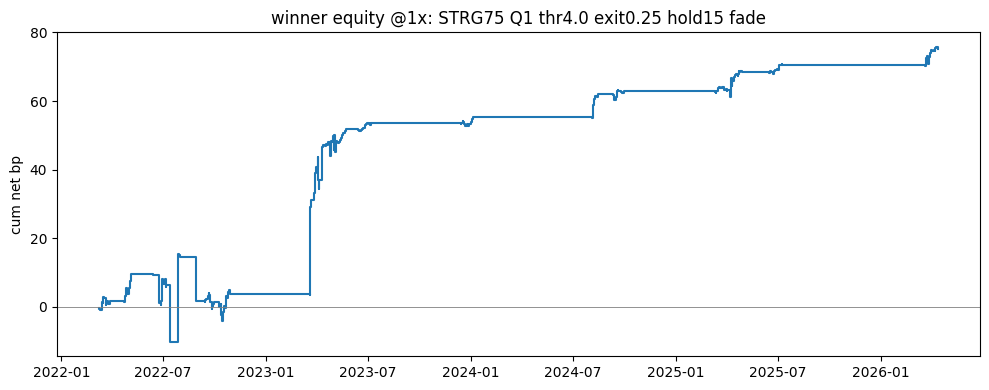

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.step(daily_w.index, daily_w.cumsum().values, where="post")
ax.axhline(0, color="gray", lw=0.6)
ax.set_title(f"winner equity @1x: {w['book']} Q{int(w['rank'])} "
             f"thr{w['thr']} exit{w['exit_frac']} hold{int(w['max_hold'])} "
             f"{w['direction']}")
ax.set_ylabel("cum net bp")
plt.tight_layout()
plt.show()

## 4. Per-trade distribution of the winner

In [6]:
print(tl[["symbol", "entry", "exit", "entry_rich", "side", "sessions",
          "gross_bp", "net_bp"]].round(2).to_string(index=False))
print(f"\nper-trade: mean {tl['net_bp'].mean():+.2f}  median "
      f"{tl['net_bp'].median():+.2f}  sd {tl['net_bp'].std():.2f}  "
      f"min {tl['net_bp'].min():+.2f}  max {tl['net_bp'].max():+.2f}")
top_share = tl["net_bp"].max() / tl["net_bp"].sum() \
    if tl["net_bp"].sum() > 0 else np.nan
print(f"largest trade / total: {top_share:.0%}"
      if np.isfinite(top_share) else "")

symbol      entry       exit  entry_rich  side  sessions  gross_bp  net_bp
SFRM22 2022-03-09 2022-03-30        6.00  -1.0        15      2.25    1.75
SFRM22 2022-04-22 2022-05-05        5.15  -1.0         9      8.25    7.75
SFRU22 2022-06-13 2022-08-29        8.77  -1.0        14     -7.21   -7.71
SFRZ22 2022-09-14 2022-10-05        6.00  -1.0        15      0.25   -0.25
SFRZ22 2022-10-07 2022-10-28        6.24  -1.0        15      2.75    2.25
SFRM23 2023-03-20 2023-04-13        5.75  -1.0        15     43.97   43.47
SFRM23 2023-04-17 2023-05-08        8.21  -1.0        15      1.25    0.75
SFRM23 2023-05-10 2023-05-24        5.75  -1.0        10      4.25    3.75
SFRU23 2023-06-14 2023-07-07        7.50  -1.0        15      2.25    1.75
SFRH24 2023-12-14 2024-01-08        4.75  -1.0        15      2.25    1.75
SFRU24 2024-08-05 2024-08-14        7.33  -1.0         7      7.25    6.75
SFRZ24 2024-09-11 2024-10-02        5.00  -1.0        15      1.50    1.00
SFRM25 2025-03-12 2025-04